In [3]:
!pip install -q umap-learn

In [1]:
pip install -q sentence-transformers torch tqdm

Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install -q transformers datasets accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import re
import torch.nn as nn
import torch
from sentence_transformers import SentenceTransformer
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import evaluate
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


from transformers import Trainer,AutoModelForSequenceClassification,TrainingArguments,AutoTokenizer,pipeline,AutoModelForSeq2SeqLM
from datasets import Dataset
from transformers import pipeline
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from collections import Counter
from torch.utils.data import DataLoader

# **Load Datasets**

In [4]:

reviews_clean=pd.read_csv("/kaggle/input/datasets/siddharth1008/all-embeddings/reviews_clean_ready.csv")
review_clusters=pd.read_csv("/kaggle/input/datasets/siddharth1008/all-embeddings/reviews_with_clusters.csv")
review_embeddings_index=pd.read_csv("/kaggle/input/datasets/siddharth1008/all-embeddings/reviews_with_embeddings_index.csv")
embeddings=np.load("/kaggle/input/datasets/siddharth1008/all-embeddings/review_embeddings.npy")


In [5]:
df = pd.read_csv("/kaggle/input/datasets/mexwell/amazon-mobile-phone-reviews/amazon_unlocked_mobile.csv")

print("Original Shape:", df.shape)
df.head()


Original Shape: (413840, 6)


,product_name,brand_name,price,rating,reviews,review_votes
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0


# **Rename Columns**

In [6]:
df = df[["product_name", "rating", "reviews"]]
df.columns = ["product_name", "rating", "review_text"]
df = df.dropna(subset=["review_text", "rating", "product_name"])
df.head(10)


,product_name,rating,review_text
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",5,I feel so LUCKY to have found this used (phone...
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",4,"nice phone, nice up grade from my pantach revu..."
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",5,Very pleased
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",4,It works good but it goes slow sometimes but i...
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",4,Great phone to replace my lost phone. The only...
5,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",1,I already had a phone with problems... I know ...
6,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",2,The charging port was loose. I got that solder...
7,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",2,"Phone looks good but wouldn't stay charged, ha..."
8,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",5,I originally was using the Samsung S2 Galaxy f...
9,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",3,It's battery life is great. It's very responsi...


# **Dataset Info**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 413770 entries, 0 to 413839
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   product_name  413770 non-null  object
 1   rating        413770 non-null  int64 
 2   review_text   413770 non-null  object
dtypes: int64(1), object(2)
memory usage: 12.6+ MB


# **Dataset Description**

In [8]:
df.describe()

,rating
count,413770.000000
mean,3.819608
std,1.548209
min,1.000000
25%,3.000000
50%,5.000000
75%,5.000000
max,5.000000


# **Keep valid ratings only:**

In [9]:
df = df[df["rating"].between(1, 5)]
df

,product_name,rating,review_text
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",5,I feel so LUCKY to have found this used (phone...
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",4,"nice phone, nice up grade from my pantach revu..."
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",5,Very pleased
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",4,It works good but it goes slow sometimes but i...
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",4,Great phone to replace my lost phone. The only...
...,...,...,...
413835,Samsung Convoy U640 Phone for Verizon Wireless...,5,another great deal great price
413836,Samsung Convoy U640 Phone for Verizon Wireless...,3,Ok
413837,Samsung Convoy U640 Phone for Verizon Wireless...,5,Passes every drop test onto porcelain tile!
413838,Samsung Convoy U640 Phone for Verizon Wireless...,3,I returned it because it did not meet my needs...


# **Basic Text Cleaning Function**

In [10]:
def clean_text(text):
    text = str(text).lower()
    
    # remove HTML tags
    text = re.sub(r"<.*?>", " ", text)
    
    # remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)
    
    # remove special characters
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    
    # remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

df["review_text"] = df["review_text"].apply(clean_text)

# **Remove Very Short And Duplicate Reviews**

In [11]:
df["review_length"] = df["review_text"].apply(lambda x: len(x.split()))

df = df[df["review_length"] >= 5]

df = df.drop_duplicates(subset=["review_text"])

# **Create Sentiment Label (From Rating)**

In [12]:
def rating_to_sentiment(r):
    if r >= 4:
        return "positive"
    elif r == 3:
        return "neutral"
    else:
        return "negative"

df["sentiment"] = df["rating"].apply(rating_to_sentiment)

# **Final Dataset Check**

In [13]:
print("Final Shape:", df.shape)

counts = df["sentiment"].value_counts()
percent=df['sentiment'].value_counts(normalize=True)*100

imbalance_df=pd.DataFrame({
    "Count":counts,
    "Percentage(%)": percent.round(2)
})
print(imbalance_df)

Final Shape: (146149, 5)
           Count  Percentage(%)
sentiment                      
positive   90479          61.91
negative   42071          28.79
neutral    13599           9.30


# **Save Cleaned CSV**

In [14]:
df.head(10)
df.to_csv("reviews_clean_ready.csv", index=False)

In [15]:
df = pd.read_csv("reviews_clean_ready.csv")

print(df.shape)
df.head()

(146149, 5)


,product_name,rating,review_text,review_length,sentiment
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",5,i feel so lucky to have found this used phone ...,72,positive
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",4,nice phone nice up grade from my pantach revue...,40,positive
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",4,it works good but it goes slow sometimes but i...,17,positive
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",4,great phone to replace my lost phone the only ...,44,positive
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",1,i already had a phone with problems i know it ...,81,negative


In [48]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


# Load Sentence Transformer Model

In [18]:
model = SentenceTransformer(
    "all-MiniLM-L6-v2",
    device=device
)

texts = df["review_text"].tolist()

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

# **Generate Embeddings**

In [19]:
batch_size = 128 

embeddings = model.encode(
    texts,
    batch_size=batch_size,
    show_progress_bar=True,
    convert_to_numpy=True
)

Batches:   0%|          | 0/1142 [00:00<?, ?it/s]

# **Verify Output**

In [20]:
print("Embedding shape:", embeddings.shape)

Embedding shape: (146149, 384)


In [21]:
embeddings

array([[-0.08474668, -0.03469365,  0.0691149 , ..., -0.00128737,
         0.0112517 ,  0.06538679],
       [-0.07874834,  0.02115542,  0.11149291, ...,  0.0505067 ,
        -0.06740016,  0.08797723],
       [-0.10769997,  0.0178199 ,  0.07806552, ...,  0.01235678,
         0.01822078,  0.06620919],
       ...,
       [-0.07499988, -0.01192594, -0.00070031, ...,  0.00811884,
         0.05130723,  0.05726709],
       [-0.056407  ,  0.08009452, -0.02380845, ..., -0.05089994,
        -0.04485128,  0.02165126],
       [-0.01040515, -0.03173742,  0.06590056, ..., -0.01871433,
         0.03719183,  0.02570054]], dtype=float32)

# **Save Embeddings**

In [22]:
np.save("review_embeddings.npy", embeddings)
df.to_csv("reviews_with_embeddings_index.csv", index=False) 

# **Quick Test**

In [25]:
query = model.encode(["battery drains quickly"])

scores = cosine_similarity(query, embeddings)[0]

top_idx = scores.argsort()[-5:][::-1]

df.iloc[top_idx][["product_name", "review_text"]]

,product_name,review_text
48438,HTC Desire 610 8GB Unlocked GSM 4G LTE Quad-Co...,the battery is draining very fast
125265,Samsung Galaxy S6 Edge SM-G925 Factory Unlocke...,battery drains fast am thinking of returning soon
34410,BLU PURE XL Smartphone - 4G LTE GSM Unlocked -...,battery power drained too fast
61189,LG Electronics G3 D855 32GB Unlocked Internati...,so far so good battery is draining fast
48407,"HTC Deluxe - 4G LTE GSM Factory Unlocked, 5"" A...",very slow and battery drains quickly not satis...


# **Load Embeddings**

In [16]:
df = pd.read_csv("/kaggle/input/datasets/siddharth1008/all-embeddings/reviews_with_embeddings_index.csv")
embeddings = np.load("/kaggle/input/datasets/siddharth1008/all-embeddings/review_embeddings.npy")

print(df.shape)
print(embeddings.shape)

(146149, 5)
(146149, 384)


# PCA Reduction Of Embedding Matrix

In [17]:
pca = PCA(n_components=50, random_state=42)
embeddings_reduced = pca.fit_transform(embeddings)

print(embeddings_reduced.shape)

(146149, 50)


# Define number of clusters

In [18]:
num_clusters = 20

In [19]:
kmeans = MiniBatchKMeans(
    n_clusters=num_clusters,
    batch_size=2048,
    random_state=42
)

clusters = kmeans.fit_predict(embeddings_reduced)

In [20]:
df["cluster_id"] = clusters

In [21]:
df.to_csv("reviews_with_clusters.csv", index=False)

# Loop Through Clusters

In [22]:
for i in range(num_clusters):
    print("\n" + "="*50)
    print(f"CLUSTER {i}")
    
    sample_reviews = df[df["cluster_id"] == i]["review_text"].head(5)
    
    for review in sample_reviews:
        print("-", review)


CLUSTER 0
- ordered this phone as a replacement for the same model until my contract expires and i can get a new one seller confirmation said delivery could take up to 7 days seller sent out the phone within hours of receiving the order and i had the phone the next day phone looks better than described was able to transfer data from the old one to the new one with no problems highly recommend this seller
- we just received the phone a few days ago put in the consumer cellular sim card and it is ready to go the phone seems very nice even though we have not come close to discovering all of the things it will do it has a large number of ring tones built in
- delivery was fast the overall quality of the phone is just like the price very cheap not a good quality camera so that is one feature i do not use at all and also not very durable my screen was damaged from a 3 inch drop however i do suppose you get what you pay for but after only having it for a month i am very willing to just buy a

In [23]:
sample_size = 10000

# choose random embeddings
sample_idx = np.random.choice(
    len(embeddings),
    sample_size,
    replace=False  #  pick only unique clusters 
)

# extract sample embeddings
emb_sample = embeddings[sample_idx]

# extract labels of those sample embeddings
cluster_sample = df.iloc[sample_idx]["cluster_id"].values

# UMAP Visualization

In [24]:
reducer = umap.UMAP(
    n_components=2,  # 2 dimensions
    n_neighbors=15,   
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

embedding_2d = reducer.fit_transform(emb_sample)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


# **Plot Clusters**

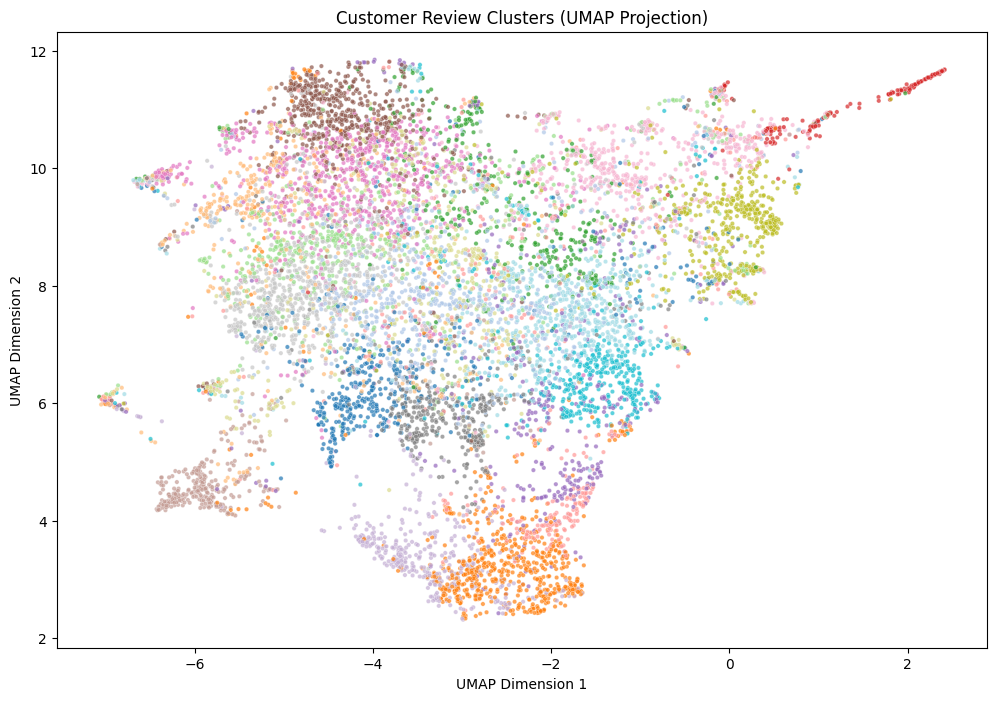

In [25]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    x=embedding_2d[:,0],
    y=embedding_2d[:,1],
    hue=cluster_sample,
    palette="tab20",
    s=10,
    alpha=0.7,
    legend=False
)

plt.title("Customer Review Clusters (UMAP Projection)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")

plt.show()

# **Label Mapping Of Clustering**

In [26]:
cluster_to_label = {
    2: "positive_feedback",
    9: "positive_feedback",
    15: "positive_feedback",
    17: "positive_feedback",

    1: "performance_complaint",
    3: "performance_complaint",
    4: "performance_complaint",
    10: "performance_complaint",

    7: "usability_issue",
    13: "usability_issue",

    8: "bug_report",
    18: "bug_report",
    19: "bug_report",
    16: "bug_report",

    0: "general_feedback",
    12: "general_feedback",
    5: "general_feedback",
    6: "general_feedback",
    14: "general_feedback"
}

In [27]:
df

,product_name,rating,review_text,review_length,sentiment,cluster_id
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",5,i feel so lucky to have found this used phone ...,72,positive,5
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",4,nice phone nice up grade from my pantach revue...,40,positive,12
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",4,it works good but it goes slow sometimes but i...,17,positive,1
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",4,great phone to replace my lost phone the only ...,44,positive,1
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",1,i already had a phone with problems i know it ...,81,negative,18
...,...,...,...,...,...,...
146144,Samsung Convoy U640 Phone for Verizon Wireless...,4,works great and picks up signal in place my ot...,13,positive,7
146145,Samsung Convoy U640 Phone for Verizon Wireless...,5,great phone large keys best flip phone i have ...,10,positive,3
146146,Samsung Convoy U640 Phone for Verizon Wireless...,5,pros works great very durable easy to navigate...,22,positive,17
146147,Samsung Convoy U640 Phone for Verizon Wireless...,5,just as described perfect for the price,7,positive,2


# **Apply Labels to Dataset**

In [28]:
df["category"] = df["cluster_id"].map(cluster_to_label)
df[["review_text", "cluster_id", "category"]].head(15)

,review_text,cluster_id,category
0,i feel so lucky to have found this used phone ...,5,general_feedback
1,nice phone nice up grade from my pantach revue...,12,general_feedback
2,it works good but it goes slow sometimes but i...,1,performance_complaint
3,great phone to replace my lost phone the only ...,1,performance_complaint
4,i already had a phone with problems i know it ...,18,bug_report
5,the charging port was loose i got that soldere...,18,bug_report
6,phone looks good but wouldn t stay charged had...,18,bug_report
7,i originally was using the samsung s2 galaxy f...,12,general_feedback
8,it s battery life is great it s very responsiv...,12,general_feedback
9,my fiance had this phone previously but caused...,1,performance_complaint


# **Handle Missing Labels**

In [29]:
df["category"].isna().sum()
df = df.dropna(subset=["category"])

# **Verify Label Distribution**

In [30]:
df["category"].value_counts()

category
general_feedback         35707
positive_feedback        35122
performance_complaint    28852
bug_report               27297
usability_issue          14253
Name: count, dtype: int64

# **Multi-Class Feedback Classifier**

# Encode Labels

In [31]:
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["category"])

num_labels = len(label_encoder.classes_)
print(label_encoder.classes_)

['bug_report' 'general_feedback' 'performance_complaint'
 'positive_feedback' 'usability_issue']


/tmp/ipykernel_55/441971560.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["label"] = label_encoder.fit_transform(df["category"])


In [32]:
df

,product_name,rating,review_text,review_length,sentiment,cluster_id,category,label
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",5,i feel so lucky to have found this used phone ...,72,positive,5,general_feedback,1
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",4,nice phone nice up grade from my pantach revue...,40,positive,12,general_feedback,1
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",4,it works good but it goes slow sometimes but i...,17,positive,1,performance_complaint,2
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",4,great phone to replace my lost phone the only ...,44,positive,1,performance_complaint,2
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",1,i already had a phone with problems i know it ...,81,negative,18,bug_report,0
...,...,...,...,...,...,...,...,...
146144,Samsung Convoy U640 Phone for Verizon Wireless...,4,works great and picks up signal in place my ot...,13,positive,7,usability_issue,4
146145,Samsung Convoy U640 Phone for Verizon Wireless...,5,great phone large keys best flip phone i have ...,10,positive,3,performance_complaint,2
146146,Samsung Convoy U640 Phone for Verizon Wireless...,5,pros works great very durable easy to navigate...,22,positive,17,positive_feedback,3
146147,Samsung Convoy U640 Phone for Verizon Wireless...,5,just as described perfect for the price,7,positive,2,positive_feedback,3


# Save mapping

In [33]:
label_mapping = dict(zip(label_encoder.classes_, range(num_labels)))
print(label_mapping)

{'bug_report': 0, 'general_feedback': 1, 'performance_complaint': 2, 'positive_feedback': 3, 'usability_issue': 4}


# Train/Test Split

In [34]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

# Convert to HuggingFace Dataset

In [35]:
train_dataset = Dataset.from_pandas(train_df[["review_text", "label"]])
test_dataset = Dataset.from_pandas(test_df[["review_text", "label"]])

# Tokenization

In [40]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(
        examples["review_text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )
train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/112984 [00:00<?, ? examples/s]

Map:   0%|          | 0/28247 [00:00<?, ? examples/s]

In [41]:
num_labels = df["label"].nunique()

# Load Model

In [42]:
model_path="/kaggle/input/datasets/siddharth1008/review-classifier"
tokenizer=AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(
    model_path,
    num_labels=num_labels
)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

# Training Arguments

In [37]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    fp16=True
)

# Define Metrics

In [43]:
# Accuracy and F1 from evaluate library

accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred   # logits -> raw model predictions  labels-> true labels
    predictions = np.argmax(logits, axis=1)  # give index of largest probability for each review

    return {
        "accuracy": accuracy.compute(
            predictions=predictions,
            references=labels
        )["accuracy"],

        "f1": f1.compute(
            predictions=predictions,
            references=labels,
            average="weighted"
        )["f1"],
    }

# Convert to Pytorch Tensors

In [44]:
train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"] # input_ids is tokenized review text , attention mask tells where is padding token(0) and where is actual token(1) , label is true label
)

test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)



In [67]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step,Training Loss
500,2.107027
1000,1.629755
1500,1.479812
2000,1.417177
2500,1.367081
3000,1.291952
3500,1.230075
4000,1.069659
4500,1.033187
5000,1.030861


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=10593, training_loss=1.0984703603416983, metrics={'train_runtime': 2460.4433, 'train_samples_per_second': 137.761, 'train_steps_per_second': 4.305, 'total_flos': 1.122562297433088e+16, 'train_loss': 1.0984703603416983, 'epoch': 3.0})

In [68]:
trainer.evaluate()

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


{'eval_loss': 1.1368696689605713,
 'eval_accuracy': 0.7864197967925798,
 'eval_f1': 0.7868392693617,
 'eval_runtime': 88.8277,
 'eval_samples_per_second': 317.998,
 'eval_steps_per_second': 19.881,
 'epoch': 3.0}

# Save Model

In [69]:
trainer.save_model("review_classifier")
tokenizer.save_pretrained("review_classifier")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('review_classifier/tokenizer_config.json', 'review_classifier/tokenizer.json')

# Test With New Review

In [45]:
# hugging face pipeline API
classifier = pipeline(
    "text-classification",
    model="/kaggle/input/datasets/siddharth1008/review-classifier",
    tokenizer="/kaggle/input/datasets/siddharth1008/review-classifier"
)

# Test a new review
classifier("battery drains very fast")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[{'label': 'LABEL_0', 'score': 0.9964458346366882}]

In [46]:
model_path="/kaggle/input/datasets/siddharth1008/review-classifier"
tokenizer=AutoTokenizer.from_pretrained(model_path)
model=AutoModelForSequenceClassification.from_pretrained(model_path)
model.eval()


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


# **Model Error Analysis**

In [49]:
model.to(device)
model.eval()

all_preds = []
all_labels = []

loader = DataLoader(test_dataset, batch_size=32)

# iterate over test dataset
for i, batch in enumerate(loader):

    # print progress
    if i % 50 == 0:
        print(i)

    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels = batch["label"].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

    preds = torch.argmax(outputs.logits, dim=1)

    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())

y_pred = np.array(all_preds)
y_true = np.array(all_labels)

cm = confusion_matrix(y_true, y_pred)

0
50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850


In [75]:
print(classification_report(labels, preds))

              precision    recall  f1-score   support

           0       0.83      0.81      0.82      5459
           1       0.78      0.79      0.79      7142
           2       0.72      0.75      0.74      5770
           3       0.84      0.82      0.83      7025
           4       0.73      0.73      0.73      2851

    accuracy                           0.79     28247
   macro avg       0.78      0.78      0.78     28247
weighted avg       0.79      0.79      0.79     28247



# Find Misclassified Reviews

In [50]:
test_df = test_df.reset_index(drop=True)

test_df["predicted"] = y_pred
test_df["true"] = y_true

errors = test_df[test_df["predicted"] != test_df["true"]]

errors.head(10)

,product_name,rating,review_text,review_length,sentiment,cluster_id,category,label,predicted,true
13,Samsung Galaxy Y GT-S5360t Unlocked GSM Quadba...,1,other reviewers may be surprised to see my rev...,229,negative,19,bug_report,0,3,0
14,Blackberry 9650 Bold Unlocked GSM Smartphone w...,1,blackberry 9650 bold this product did not work...,27,negative,14,general_feedback,1,0,1
20,Nokia 7020 Unlocked Cell Phones,5,i purchased nokia 7720 after using the contrac...,31,positive,16,bug_report,0,1,0
23,Blackberry Pearl 9100 GSM Phone with 3G Suppor...,5,everything has been great i have to test it wh...,24,positive,13,usability_issue,4,1,4
24,Samsung Galaxy S Blaze 4G SGH-T769 GSM Black -...,5,this phone is great i got it for my daughter a...,52,positive,1,performance_complaint,2,1,2
43,"Polaroid Snap S55BK 5.5"" Unlocked Phone Androi...",4,the polaroid snap s55pk has a lot of awesome f...,707,positive,4,performance_complaint,2,1,2
47,BLU Life Pure Unlocked Phone (Black),2,blu socks i bought this phone hopping that the...,40,negative,14,general_feedback,1,2,1
62,Motorola_w755 (Purple) with 1.3 Megapixel- Cam...,5,my wife has the purple and i have the black ph...,22,positive,17,positive_feedback,3,1,3
63,BlackBerry 8520 Unlocked Phone with 2 MP Camer...,1,i got it several days ago as i open the parcel...,100,negative,16,bug_report,0,1,0
68,Indigi 713-2ga Unlocked Cell 2-in-1 Phablet 7-...,1,i was not satisfied at all with my purchase i ...,85,negative,0,general_feedback,1,4,1


# Add Prediction Column

In [51]:
trainer=Trainer(model=model)
predictions = trainer.predict(train_dataset)

preds = predictions.predictions.argmax(axis=1)

df_predictions = train_df.copy()

df_predictions["predicted_cluster"] = preds

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


In [52]:
df_predictions

,product_name,rating,review_text,review_length,sentiment,cluster_id,category,label,predicted_cluster
74611,Moto G Plus (4th Gen.) Unlocked - Black - 16GB...,2,my relationship with this phone went downhill ...,84,negative,1,performance_complaint,2,2
52041,HTC One M8 - Factory Unlocked 32GB - US Warran...,4,i m pretty happy with this smartphone it s the...,109,positive,10,performance_complaint,2,2
30950,BLU Energy X Plus Smartphone - With 4000 mAh S...,5,i bought this little gem for a couple of reaso...,107,positive,1,performance_complaint,2,2
109233,Samsung Galaxy Note 3 N900 32GB Unlocked GSM 4...,4,the photo editing is not as good as the iphone...,26,positive,10,performance_complaint,2,2
128686,Samsung i897 Captivate Android Smartphone Gala...,5,navectron has been very helpful i ordered the ...,45,positive,16,bug_report,0,0
...,...,...,...,...,...,...,...,...,...
120040,Samsung Galaxy S4 SGH-I337 Unlocked GSM Smartp...,5,the phone works great and haven t had any issu...,20,positive,1,performance_complaint,2,2
22400,BlackBerry Bold 9700 Unlocked GSM 3G World Pho...,2,thanks amazon thanks for the timely delivery o...,65,negative,14,general_feedback,1,1
13579,Apple iPhone 5S 32 gb (Space Gray) - AT&T,5,brand new sealed in box took awhile for it to ...,20,positive,14,general_feedback,1,1
61103,LG Electronics G3 D855 32GB Unlocked Internati...,5,its an amazing phone and it works perfectly in...,12,positive,15,positive_feedback,3,3


In [55]:
cluster_examples = (
    df_predictions
    .groupby("predicted_cluster")["review_text"] # group clusters together and select top 3 review text from each cluster
    .apply(lambda x: x.iloc[:3])
)

cluster_examples

predicted_cluster        
0                  128686    navectron has been very helpful i ordered the ...
                   102540    good lil charger looks good too be aware it do...
                   21232     returned item to seller he refuse to contact m...
1                  123190    the phone is amazing it came with the box char...
                   25010     the phone came in in perfect condition everyth...
                   117333    just like a brand new phone and i ve already u...
2                  74611     my relationship with this phone went downhill ...
                   52041     i m pretty happy with this smartphone it s the...
                   30950     i bought this little gem for a couple of reaso...
3                  37308                  the sound of this phone is very poor
                   56438     best android phone i ever purchased amazon cus...
                   39914     excellent phone and excellent seller thank you...
4                  27715  

# Count of each category

In [56]:
insights = (
    df_predictions["category"]
    .value_counts()
    .reset_index()
)

insights.columns = ["Category", "Review Count"]

insights

,Category,Review Count
0,general_feedback,28565
1,positive_feedback,28097
2,performance_complaint,23082
3,bug_report,21838
4,usability_issue,11402


# Plot Count of Each Category

/tmp/ipykernel_55/3136257674.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


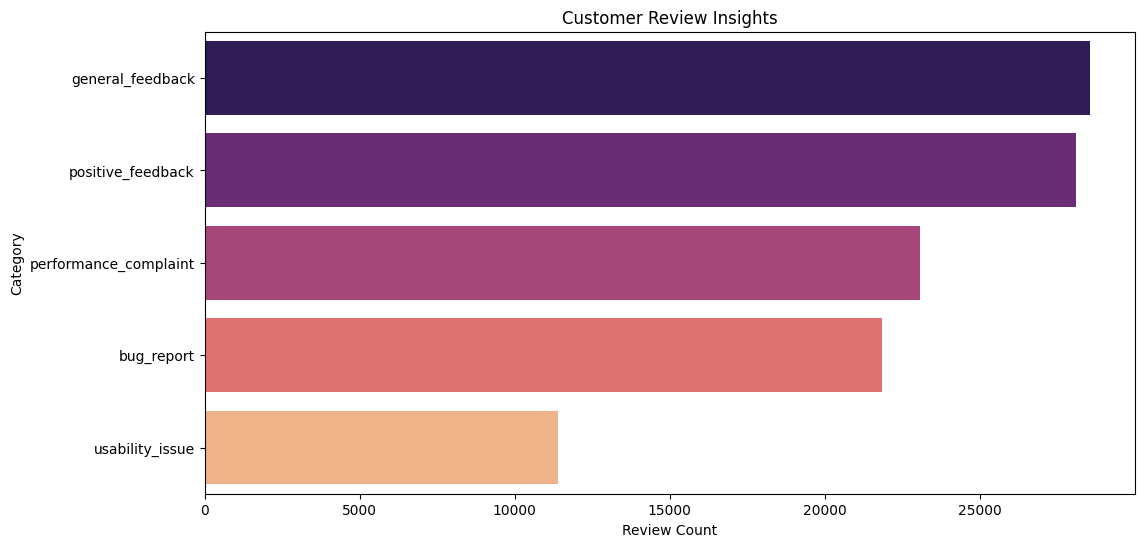

In [57]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=insights,
    x="Review Count",
    y="Category",
    palette="magma"
)

plt.title("Customer Review Insights")

plt.show()

# **Summarizing Cluster Reviews** 

# Take 10 sample reviews

In [58]:
cluster_samples = (
    df_predictions
    .groupby("predicted_cluster")["review_text"]
    .apply(lambda x: x.sample(min(10, len(x))))
    .reset_index()
)

# Combine reviews into one text

In [59]:
cluster_text = (
    cluster_samples
    .groupby("predicted_cluster")["review_text"]
    .apply(lambda x: " ".join(x))
    .reset_index()
)

# Load flan-t5-base model

In [60]:
model_name = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

T5ForConditionalGeneration(
  (shared): Embedding(32128, 768)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 768)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=768, out_features=768, bias=False)
              (k): Linear(in_features=768, out_features=768, bias=False)
              (v): Linear(in_features=768, out_features=768, bias=False)
              (o): Linear(in_features=768, out_features=768, bias=False)
              (relative_attention_bias): Embedding(32, 12)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseGatedActDense(
              (wi_0): Linear(in_features=768, out_features=2048, bias=False)
              (wi_1): Linear(in_features=768, out_features=2048, bias=False)
              (wo):

# Summarize Reviews Function

In [61]:
def summarize_reviews(text):

    prompt = f"""
    Summarize the common issues and opinions from these customer phone reviews.

    Reviews:
    {text[:1200]}   

    Summary:
    """

    # convert prompts into inputs 
    inputs = tokenizer(
        prompt,
        return_tensors="pt", # return pytorch tensors 
        truncation=True  # cut the extra tokens
    ).to(device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=80,  # summary should contain max 80 tokens
        num_beams=4
    )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)  # convert output tokens back to text and skip <pad> </s> tokens

In [62]:
cluster_reviews = df_predictions.groupby("predicted_cluster")["review_text"].apply(
    lambda x: "\n".join(x.sample(min(20, len(x))))
).reset_index()

# Summarize Reviews

In [63]:
cluster_reviews["summary"] = cluster_reviews["review_text"].apply(summarize_reviews)

# Print Clusters Summaries

In [64]:
for i,row in cluster_reviews.iterrows():

    print("Cluster:", row["predicted_cluster"])
    print("Summary:", row["summary"])
    print("-"*60)

Cluster: 0
Summary: Reviews: The speaker is not working, the keys and screen are so sensitive, the phone stopped working in less than 2 months, the phone started tripping out and cutting off for no reason, the only thing i received in my phone is the phone and a house charger i don t know how to open the phone or how to operate the phone can you send me the rest
------------------------------------------------------------
Cluster: 1
Summary: The picture of the product is not what you actually receive the picture also show a bluetooth headset but thats not included shipping is also very long but considering coming from china i guess i cant complain i am actually disappointed with this product again you get what you paid for the phone was brand new in the at t box with everything included amazing deal phone was unlocked and very pleased
------------------------------------------------------------
Cluster: 2
Summary: Reviews: My daughter chose this phone i was a bit reserved about buying 

# **AI Product Feature Generator**

In [65]:
def generate_feature_ideas(summary):

    prompt = f"""
Analyze the following smartphone customer feedback and suggest three product improvements.

Customer Feedback:
{summary}

List three specific improvements the company should make.
"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=120,
        do_sample=True,
        top_p=0.9  # nucleus sampling
    ) 

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# Clean Summary Text and add Feature Ideas Column

In [66]:
cluster_reviews["summary"] = cluster_reviews["summary"].str.replace("Reviews:", "")
cluster_reviews["feature_ideas"] = cluster_reviews["summary"].apply(
    lambda x: generate_feature_ideas(x[:500])
)

# Print Feature Suggestions

In [67]:
for i,row in cluster_reviews.iterrows():

    print("Cluster:", row["predicted_cluster"])
    print("Customer Insight:", row["summary"])
    print("AI Feature Suggestions:", row["feature_ideas"])
    print("="*70)

Cluster: 0
Customer Insight:  The speaker is not working, the keys and screen are so sensitive, the phone stopped working in less than 2 months, the phone started tripping out and cutting off for no reason, the only thing i received in my phone is the phone and a house charger i don t know how to open the phone or how to operate the phone can you send me the rest
AI Feature Suggestions: A more reliable camera
Cluster: 1
Customer Insight: The picture of the product is not what you actually receive the picture also show a bluetooth headset but thats not included shipping is also very long but considering coming from china i guess i cant complain i am actually disappointed with this product again you get what you paid for the phone was brand new in the at t box with everything included amazing deal phone was unlocked and very pleased
AI Feature Suggestions: The picture of the product is not what you actually receive the picture also show a Bluetooth headset but that's not included shippin

# **Entity Extraction Function**

# Feature Dictionary

In [68]:
feature_dict = {
    "camera": "Camera",
    "battery": "Battery",
    "charging": "Battery",
    "screen": "Display",
    "display": "Display",
    "microphone": "Microphone",
    "speaker": "Speaker",
    "sound": "Speaker",
    "wifi": "Connectivity",
    "network": "Connectivity",
    "signal": "Connectivity",
    "performance": "Performance",
    "slow": "Performance",
    "lag": "Performance",
    "software": "Software",
    "app": "Software",
    "price": "Price",
    "accessories": "Accessories",
}

# Extract Entities Function

In [69]:
def extract_entities(review):

    review_lower = review.lower()

    product = "Smartphone"
    feature = "Other"
    severity = "Low"
    solution = "No action required"

    # detect feature
    for key, value in feature_dict.items():
        if key in review_lower:
            feature = value
            break

    # detect severity
    if any(word in review_lower for word in ["broken","doesnt work","crash","defect","problem","bad"]):
        severity = "High"
    elif any(word in review_lower for word in ["slow","poor","issue","not good"]):
        severity = "Medium"

    # suggest solution
    solution_map = {
        "Camera": "Improve camera hardware or software",
        "Battery": "Improve battery capacity or charging system",
        "Display": "Improve screen quality",
        "Microphone": "Fix microphone hardware",
        "Speaker": "Improve audio hardware",
        "Connectivity": "Improve network module",
        "Performance": "Optimize software performance",
        "Software": "Release software updates",
        "Accessories": "Ensure full package contents",
        "Price": "Adjust pricing strategy"
    }

    solution = solution_map.get(feature,"No major fix needed")

    return {
        "Product": product,
        "Feature": feature,
        "Severity": severity,
        "Solution": solution
    }

# Apply Entity Extraction to Reviews

In [70]:
df_entities = df["review_text"].apply(extract_entities).apply(pd.Series)

df = pd.concat([df, df_entities], axis=1)

df[["review_text","Feature","Severity","Solution"]].head(10)

,review_text,Feature,Severity,Solution
0,i feel so lucky to have found this used phone ...,Software,Low,Release software updates
1,nice phone nice up grade from my pantach revue...,Other,Low,No major fix needed
2,it works good but it goes slow sometimes but i...,Performance,Medium,Optimize software performance
3,great phone to replace my lost phone the only ...,Other,Low,No major fix needed
4,i already had a phone with problems i know it ...,Software,High,Release software updates
5,the charging port was loose i got that soldere...,Battery,Low,Improve battery capacity or charging system
6,phone looks good but wouldn t stay charged had...,Battery,Low,Improve battery capacity or charging system
7,i originally was using the samsung s2 galaxy f...,Camera,Medium,Improve camera hardware or software
8,it s battery life is great it s very responsiv...,Battery,Medium,Improve battery capacity or charging system
9,my fiance had this phone previously but caused...,Other,High,No major fix needed


# Feature Frequency Analysis

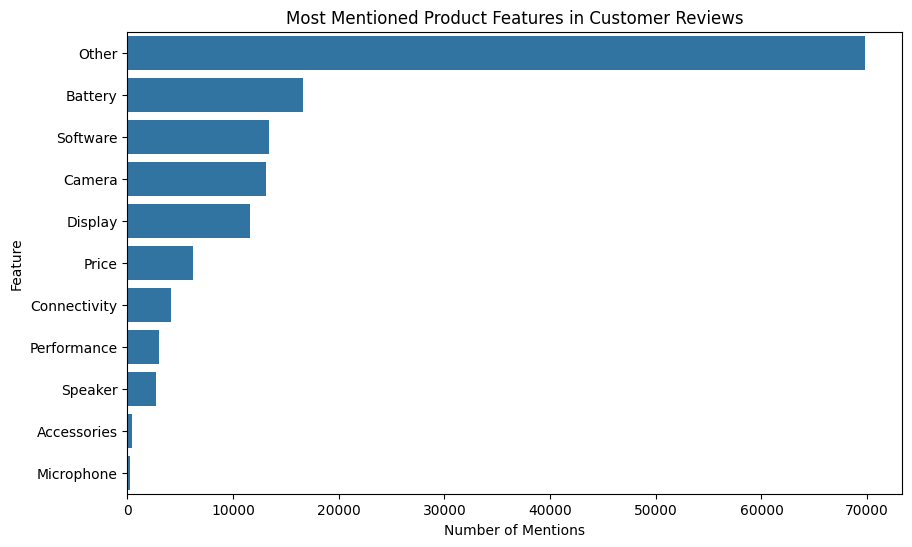

In [71]:
feature_counts = df["Feature"].value_counts()

plt.figure(figsize=(10,6))
sns.barplot(
    x=feature_counts.values,
    y=feature_counts.index
)

plt.title("Most Mentioned Product Features in Customer Reviews")
plt.xlabel("Number of Mentions")
plt.ylabel("Feature")

plt.show()

# High Severity Issue Analysis

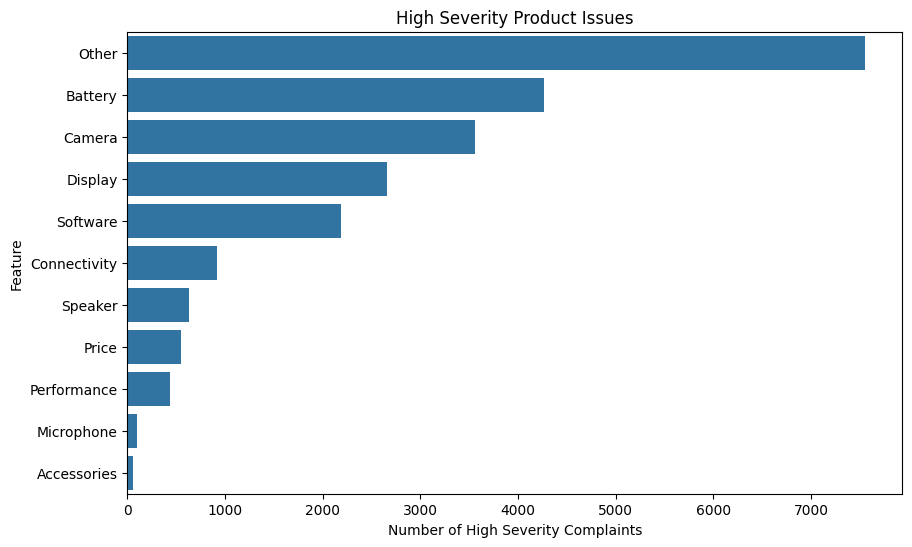

In [72]:
high_severity = df[df["Severity"] == "High"]

severity_counts = high_severity["Feature"].value_counts()

plt.figure(figsize=(10,6))

sns.barplot(
    x=severity_counts.values,
    y=severity_counts.index
)

plt.title("High Severity Product Issues")
plt.xlabel("Number of High Severity Complaints")
plt.ylabel("Feature")

plt.show()

# Feature vs Severity Heatmap

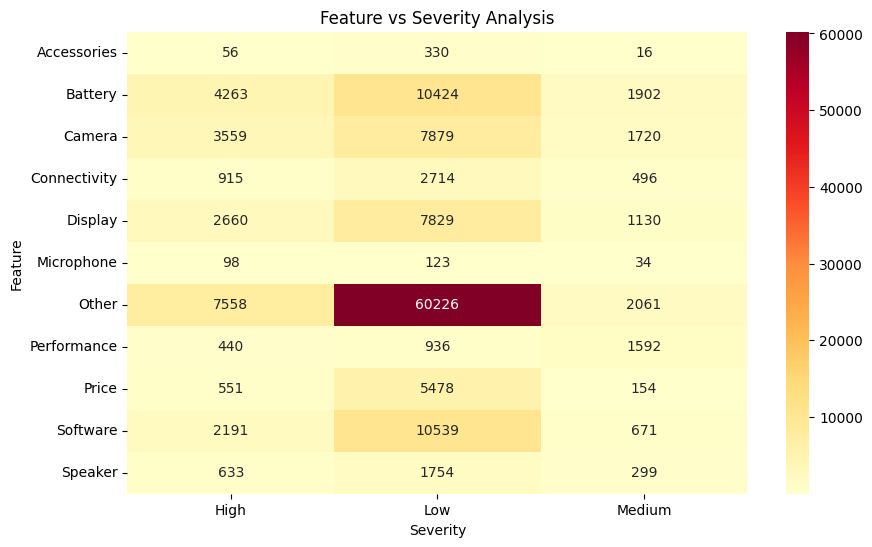

In [73]:
pivot = pd.crosstab(df["Feature"], df["Severity"])  # create feature and severity table

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap="YlOrRd", # yellow for low counts , orange -> medium counts , red -> high counts
    fmt="d"  # display numbers as integers
)

plt.title("Feature vs Severity Analysis")

plt.show()

# **Internal Conversational AI Assistant**

In [74]:
def ask_insight(question):

    q = question.lower()

    # Top complaints
    if "top complaint" in q or "top issue" in q:
        
        top = df["Feature"].value_counts().head(5)

        response = "Top customer complaints:\n"

        for f, c in top.items():
            response += f"- {f}: {c} mentions\n"

        return response


    # High severity issues
    elif "high severity" in q or "critical" in q:

        high = df[df["Severity"]=="High"]["Feature"].value_counts().head(5)

        response = "High severity product issues:\n"

        for f, c in high.items():
            response += f"- {f}: {c} complaints\n"

        return response


    # Feature specific query
    elif "battery" in q:

        subset = df[df["Feature"]=="Battery"]["review_text"].sample(3)

        response = "Sample battery complaints:\n"

        for r in subset:
            response += f"- {r[:120]}...\n"

        return response


    else:
        return "I could not understand the query. Try asking about complaints, severity, or features."

In [75]:
while True:


    question = input("Ask Insight Assistant: ")

    if question.lower() == "exit":
        break

    print(ask_insight(question))
    print()

Ask Insight Assistant:  what are some top complaints


Top customer complaints:
- Other: 69845 mentions
- Battery: 16589 mentions
- Software: 13401 mentions
- Camera: 13158 mentions
- Display: 11619 mentions




Ask Insight Assistant:  tell me about battery complaints


Sample battery complaints:
- nice phone ui or screen can be a little glitchy battery life is ok no wifi connectivity apparently this is a relatively ...
- i ll make this review brief firstly great phone for the price its not perfect but dang you sure get your moneys worth no...
- it is a very good product i feel very satisfied with it long life battery can use all apliction i want and enough memory...




Ask Insight Assistant:  what are top severity complaints


I could not understand the query. Try asking about complaints, severity, or features.



Ask Insight Assistant:  exit
